# Bài tập thực hành 2 

## Yêu cầu

Dự đoán doanh thu xe hơi Hyundai dòng Elantra trong năm 2013 và đầu 2014, dựa vào dữ liệu trước đó

## Dữ liệu

Dữ liệu được ghi trong file csv với các trường (Month, Year, ElantraSales, Unemployment, Queries, CPI_energy, CPI_all). Giá trị cần dự đoán sẽ là ElantraSales.

## Đánh giá

Đánh giá mô hình dựa trên 
* Độ đo tiêu chuẩn của ML: RMSE = $\sqrt{\text{avg}\left(y^{\left(n\right)}-\hat{y}^{\left(n\right)}\right)^{2}}$
* Độ đo của business requirements: Mean relative errors = $\text{avg}\left(\dfrac{\left|y^{\left(n\right)}-\hat{y}^{\left(n\right)}\right|}{y^{\left(n\right)}}\right)\times100\%$

# Đọc dữ liệu

In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import seaborn as sns


In [4]:
df = pd.read_csv('elantra.csv')

In [5]:
df.head()

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
1,1,2011,9659,9.1,259,229.353,221.082
2,1,2012,10900,8.2,354,244.178,227.666
3,1,2013,12174,7.9,230,242.560,231.321
4,1,2014,15326,6.6,232,247.575,234.933


In [6]:
##### exercise #####
# Yêu cầu: Sắp xếp lại thứ tự các hàng dữ liệu theo tháng/năm
# Gợi ý: sử dụng df.sort_values và df.reset_index
######################
df = df.sort_values(by=['Year', 'Month'])
df = df.reset_index(drop=True)
df.head(10)

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
1,2,2010,7966,9.8,130,209.924,217.251
2,3,2010,8225,9.9,138,209.163,217.305
3,4,2010,9657,9.9,132,209.024,217.376
4,5,2010,9781,9.6,177,206.172,217.299
5,6,2010,14245,9.4,138,204.161,217.285
6,7,2010,18215,9.5,156,206.834,217.677
7,8,2010,15181,9.5,202,208.927,218.012
8,9,2010,10062,9.5,150,209.850,218.281
9,10,2010,9497,9.5,178,216.655,219.024


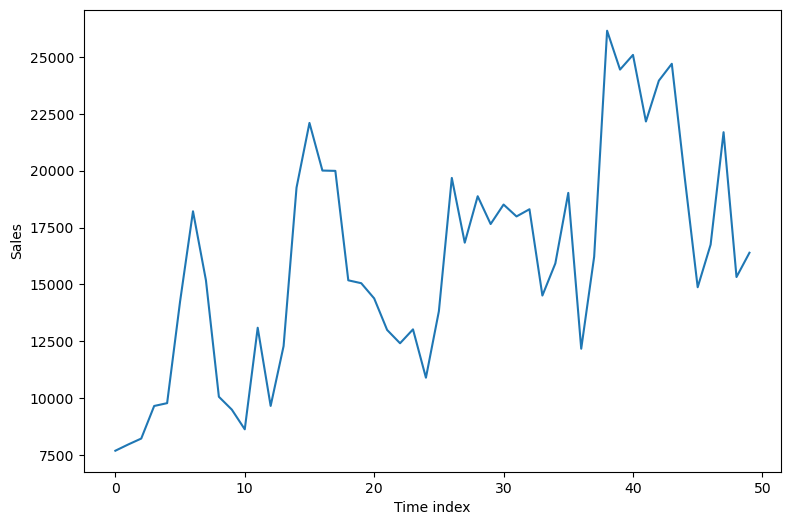

In [7]:
plt.figure(figsize=(9,6))
 
plt.plot(df.ElantraSales.values)
 
plt.xlabel('Time index')

plt.ylabel('Sales')
 
 
# function to show the plot
plt.show()

In [8]:
numeric_feats = df.columns.drop(["ElantraSales", "Month", "Year"]) 
numeric_feats

Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all'], dtype='str')

In [9]:
df_train = df[df.Year < 2013]
df_test = df[df.Year >= 2013]

y_train = df_train.ElantraSales.values
y_test = df_test.ElantraSales.values

**feature scaling**

In [10]:
# Chuẩn hóa dữ liệu bằng StandardScaler, dữ liệu được chuẩn hóa theo dạng x -> (x-mean)/std 
# Nếu x có phân phối Gauss, dữ liệu chuẩn hóa sẽ thuộc phân phối N(0,1)
sc = StandardScaler()
X_train = sc.fit_transform(df_train[numeric_feats])
X_test = sc.transform(df_test[numeric_feats])


# Xây dựng Mô hình

In [11]:
###### exercise #####
# Yêu cầu: Xây dựng và huấn luyện mô hình Linear Regression
# Gợi ý: sử dụng hàm fit() nhưng trong bài thực hành 1
######################
model1 = LinearRegression()
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Đánh giá

In [12]:
from sklearn.metrics import mean_squared_error

def relative_error(y_true, y_pred):
    errors = np.abs(y_true - y_pred)/y_true
    return np.mean(errors)*100

In [13]:
y_pred_test = model1.predict(X_test)
print ('RMSE: {:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_pred_test))))
print ('Mean relative errors: {:.1f}%'.format(relative_error(y_test, y_pred_test)))

RMSE: 5017.35
Mean relative errors: 19.0%


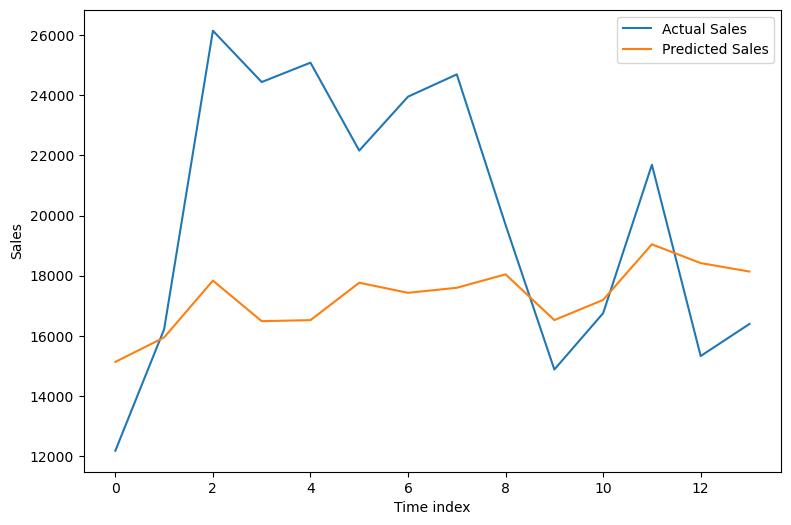

In [14]:
###### exercise #####
# Yêu cầu: Vẽ biểu đồ đường so sánh y_test và y_pred_test
# Gợi ý: sử dụng matplotlib như bài thực hành 1
######################
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
 
plt.plot(y_test, label='Actual Sales')
plt.plot(y_pred_test, label='Predicted Sales')
 
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.legend()
 
 
# function to show the plot
plt.show()

Kết quả dự đoán không khớp một chút nào so với dữ liệu thật

Lý do có thể là vì chúng ta chưa tận dụng hết thông tin của dữ liệu

Quan sát thấy doanh thu có xu hướng biến động theo từ tháng trong một năm

=> Tận dụng thông tin tháng hiệu quả. Có thể xây dựng mô hình regression với đặc trưng Month theo kiểu categorical kết hợp với các đặc trưng khác.

# Giải pháp cải tiến

In [16]:
month_onehot_train = pd.get_dummies(df_train.Month)
month_onehot_train.head()

,1,2,3,4,5,6,7,8,9,10,11,12
0,True,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False


In [17]:
###### exercise #####
# Yêu cầu: Ghép đặc trưng Month_1, ..., Month_12 vào các đặc trưng đang có, kết quả ở dạng numpy array
# Gợi ý: sử dụng np.hstack
######################
X_train = np.hstack((X_train, month_onehot_train))
X_train[0]

array([ 1.24576653, -1.25517995, -1.21438113, -1.35903692,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

In [18]:
# Tương tự với X_test
X_test = np.hstack((X_test, pd.get_dummies(df_test.Month)))

In [19]:
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred_test = model1.predict(X_test)
print ('RMSE: {:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_pred_test))))
print ('Mean relative errors: {:.1f}%'.format(relative_error(y_test, y_pred_test)))

RMSE: 3590.37
Mean relative errors: 12.8%


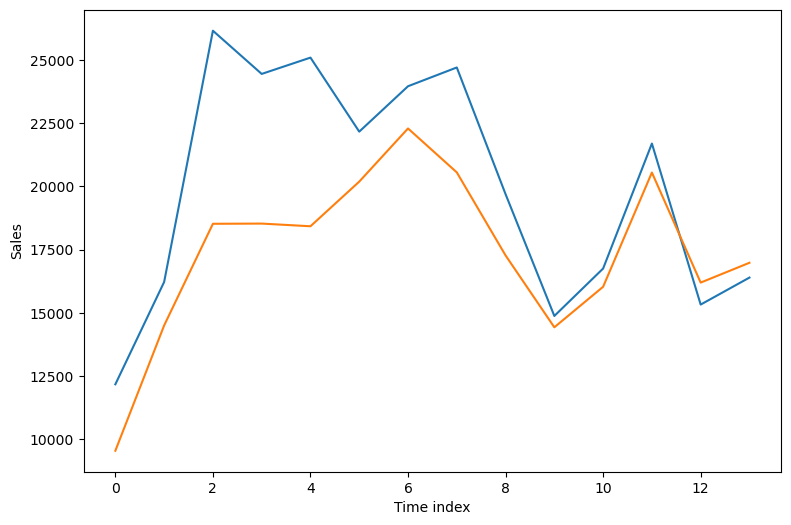

In [21]:
plt.figure(figsize=(9,6))
 
plt.plot(y_test)
plt.plot(y_pred_test)
 
plt.xlabel('Time index')

plt.ylabel('Sales')
 
 
# function to show the plot
plt.show()